<a href="https://colab.research.google.com/github/Naman1232/ML-PROJECTS/blob/main/Image_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

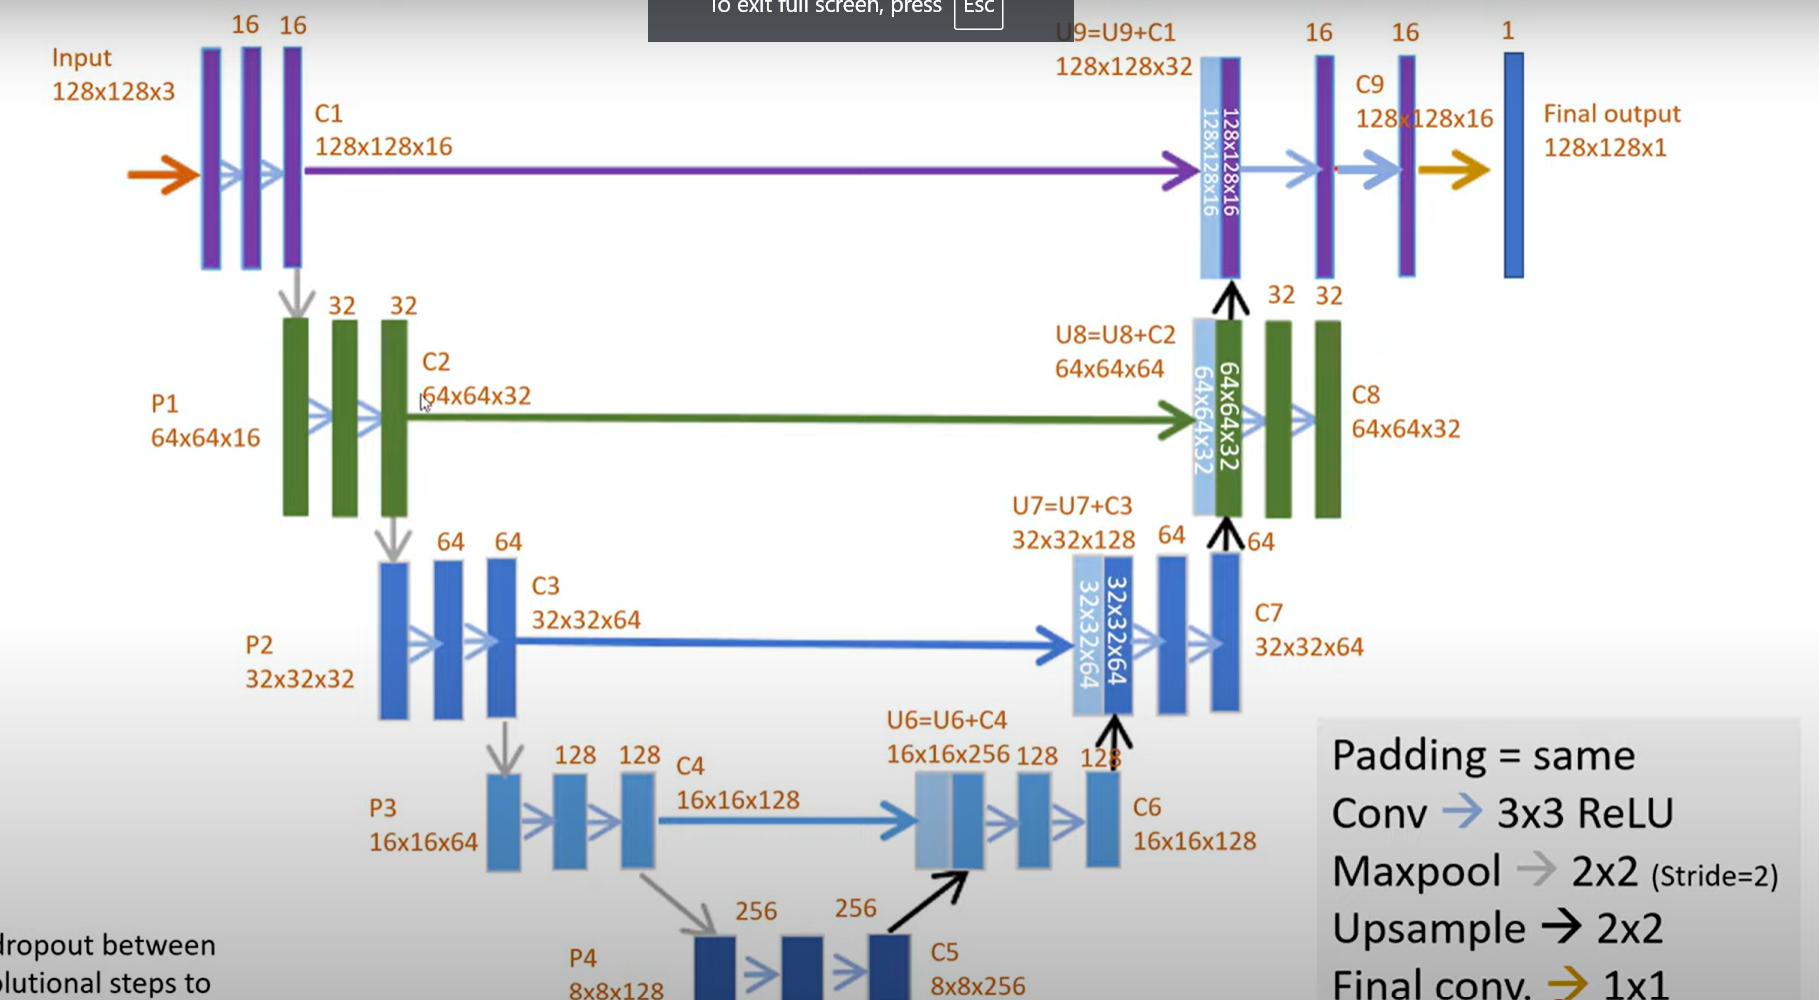

In [38]:
import tensorflow as tf
import os
import numpy as np
import random

* Tensorflow-is used to build and train models in deep learning
* OS-to walk through folders,read file names etc
* numpy-used to work with arrays
* random-used to generate a random number


In [39]:
from tqdm import tqdm
from skimage.io import imread,imshow
from skimage.transform import resize
import matplotlib.pyplot as plt

1. **`from tqdm import tqdm`**: Imports the `tqdm` library, which is used to create progress bars for loops, making it easier to track the progress of long-running tasks.
   
2. **`from skimage.io import imread, imshow`**: Imports `imread` and `imshow` from `skimage.io`. `imread` is used to read an image from a file, and `imshow` is used to display an image.

3. **`from skimage.transform import resize`**: Imports the `resize` function from `skimage.transform`, which is used to resize images to a specified shape or scale.

4. **`import matplotlib.pyplot as plt`**: Imports the `pyplot` module from the `matplotlib` library, commonly used to create various plots and graphs, including displaying images.


In [35]:
from google.colab import files
uploaded = files.upload()

Saving stage1_test.zip to stage1_test.zip
Saving stage1_train.zip to stage1_train.zip


In [36]:
!unzip '/content/stage1_train.zip' -d '/content/'
!unzip '/content/stage1_test.zip' -d '/content/'

Streaming output truncated to the last 5000 lines.
  inflating: /content/stage1_train/d751ccb64fa767a65a966061218438bd1860695d96bbef11fdb2f0d3b8dedba8/masks/4e9e99c75fad6c38a550e4e19ffa6122d9609d6a3873e9eb06b146e44eba77c1.png  
  inflating: /content/stage1_train/d751ccb64fa767a65a966061218438bd1860695d96bbef11fdb2f0d3b8dedba8/masks/6ba00b30ccb02a513dcf278445bf91e2e19307fcdb25a9349008ce6bfd48f68a.png  
  inflating: /content/stage1_train/d751ccb64fa767a65a966061218438bd1860695d96bbef11fdb2f0d3b8dedba8/masks/8ba5738a51ac3dad6d79fd943d2560f675850c93c1dfd04d5deb3941d65879c4.png  
  inflating: /content/stage1_train/d751ccb64fa767a65a966061218438bd1860695d96bbef11fdb2f0d3b8dedba8/masks/91315d20482a3d3da5c52d75df4d194e815e12e06bf13640a1ac4d9fc3ce9ff7.png  
  inflating: /content/stage1_train/d751ccb64fa767a65a966061218438bd1860695d96bbef11fdb2f0d3b8dedba8/masks/93937eb740267e15aca1212e8de6e89815ff2ddc2c13aeb54df7621d51090686.png  
  inflating: /content/stage1_train/d751ccb64fa767a65a96606121843

In [40]:
TRAIN_PATH = '/content/stage1_train/'
TEST_PATH = '/content/stage1_test/'

train_ids = next(os.walk(TRAIN_PATH))[1]
test_ids = next(os.walk(TEST_PATH))[1]

print("Train IDs:", train_ids)
print("Test IDs:", test_ids)

Train IDs: ['...']
Test IDs: ['ab298b962a63e4be9582513aaa84a5e270adba5fd2b16a50e59540524f63c3b8', 'da6c593410340b19bb212b9f6d274f95b08c0fc8f2570cd66bc5ed42c560acab', '7f4cbe0b36b5d09466476a7d4e01f4f976c67872d549f4ff47b3e1e3a2b403af', '3c4c675825f7509877bc10497f498c9a2e3433bf922bd870914a2eb21a54fd26', 'd616d323a9eeb9da1b66f8d5df671d63c092c9919cb2c0b223e29c63257c944d', '4be73d68f433869188fe5e7f09c7f681ed51003da6aa5d19ce368726d8e271ee', '9ab2d381f90b485a68b82bc07f94397a0373e3215ad20935a958738e55f3cfc2', 'd8d4bf68a76e4e4c5f21de7ac613451f7115a04db686151e78b8ec0b6a22022b', '44afae184c89e6ba55985b4d341acc1ae1e8b6ef96312064e0e6e630e022b078', 'bdc789019cee8ddfae20d5f769299993b4b330b2d38d1218646cf89e77fbbd4d', '648c8ffa496e1716017906d0bf135debfc93386ae86aa3d4adbda9a505985fd9', '432f367a4c5b5674de2e2977744d10289a064e5704b21af6607b4975be47c580', '336d3e4105766f8ad328a7ee9571e743f376f8cbcf6a969ca7e353fe3235c523', 'ade080c6618cbbb0a25680cf847f312b5e19b22bfe1cafec0436987ebe5b1e7e', '1cdbfee1951356e7b

* train and test path is used to go to the folder
* to iterate thru the subfolders we use train and test ids which iterate thru all the subfolders within the main folder



In [2]:
IMG_WIDTH=128
IMG_HEIGHT=128
IMG_CHANNELS=3

In [42]:
X_train=np.zeros((len(train_ids),IMG_HEIGHT,IMG_WIDTH,IMG_CHANNELS),dtype=np.uint8)
Y_train=np.zeros((len(train_ids),IMG_HEIGHT,IMG_WIDTH,1),dtype=bool)

### 1. **`X_train` Array:**
- **`np.zeros()`**: Creates an array with zeros.
- **Shape**: `(len(train_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)`:
  - `len(train_ids)`: Number of images.
  - `IMG_HEIGHT`, `IMG_WIDTH`: Image dimensions.
  - `IMG_CHANNELS`: Number of color channels (e.g., 3 for RGB).
- **`dtype=np.uint8`**: Each pixel is an 8-bit integer (0-255).

### 2. **`Y_train` Array:**
- **`np.zeros()`**: Creates an array with zeros.
- **Shape**: `(len(train_ids), IMG_HEIGHT, IMG_WIDTH, 1)`:
  - `len(train_ids)`: Number of images.
  - `IMG_HEIGHT`, `IMG_WIDTH`: Image dimensions.
  - `1`: Single channel (for binary masks).
- **`dtype=bool`**: Boolean values (True/False).

In [45]:
print('Resizing training images and masks')
for n,id_ in tqdm(enumerate(train_ids),total=len(train_ids)):
  path= TRAIN_PATH + id_
  img=imread(path + '/images/' + id_ + '.png')[:,:,:IMG_CHANNELS]
  img=resize(img,(IMG_HEIGHT,IMG_WIDTH),mode='constant',preserve_range=True)
  X_train[n]= img
  mask=np.zeros((IMG_HEIGHT,IMG_WIDTH,1),dtype=bool)
  for mask_file in next(os.walk(path+'/masks/'))[2]:
    mask_ =imread(path+'/masks/'+mask_file)
    mask_=np.expand_dims(resize(mask_,(IMG_HEIGHT,IMG_WIDTH),mode='constant',preserve_range=True),axis=-1)
    mask=np.maximum(mask,mask_)

  Y_train[n]=mask


Resizing training images and masks


100%|██████████| 670/670 [06:19<00:00,  1.77it/s]


1. **Iterate Through Images**:
   - You go through each subfolder (each training example) in the `train_ids` list.
   - For each image, you read it from the **`images` folder** using `imread()`.

2. **Track Progress with `tqdm`**:
   - As you process each image, the `tqdm` library shows the progress (percentage completed) to help you monitor the loop.

3. **Store Image in `X_train`**:
   - After reading the image, you store it in the `X_train` array. You're replacing one of the zeros with the actual image data.

4. **Process Masks**:
   - Now, you go through the **`masks` folder** for that image.
   - Each image might have multiple masks (e.g., 50 parts), and each mask highlights a different area or part of the object.

5. **Combine Mask Parts**:
   - For each mask image (`mask_`), you find the highlighted area (where it's `1`, meaning part of the object, and `0` means the background).
   - You then combine all these parts into one final mask. You use `np.maximum()` to combine the mask parts (because `np.maximum` takes the highest value between `mask` and `mask_`, so if any mask highlights a part, it will be marked as `1` in the final mask).

6. **Store Final Mask in `Y_train`**:
   - After processing all the mask parts, you store the final mask in the `Y_train` array. This final mask corresponds to the original image.

### In short:
- **`X_train`** holds the images.
- **`Y_train`** holds the corresponding final masks (that combine all parts from the mask images).

This process ensures that, for every image in your dataset, you have a corresponding mask (representing the full object) in `Y_train`.



In [46]:
X_test=np.zeros((len(test_ids),IMG_HEIGHT,IMG_WIDTH,IMG_CHANNELS),dtype=np.uint8)
sizes_test=[]
print('Resizing Test Images')
for n,id_ in tqdm(enumerate(test_ids),total=len(test_ids)):
  path= TEST_PATH + id_
  img=imread(path + '/images/' + id_ + '.png')[:,:,:IMG_CHANNELS]
  sizes_test.append([img.shape[0],img.shape[1]])
  img=resize(img,(IMG_HEIGHT,IMG_WIDTH),mode='constant',preserve_range=True)
  X_test[n]= img


Resizing Test Images


100%|██████████| 65/65 [00:02<00:00, 24.63it/s]


<ipython-input-49-257671d3a522>:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(X_train[image_x])


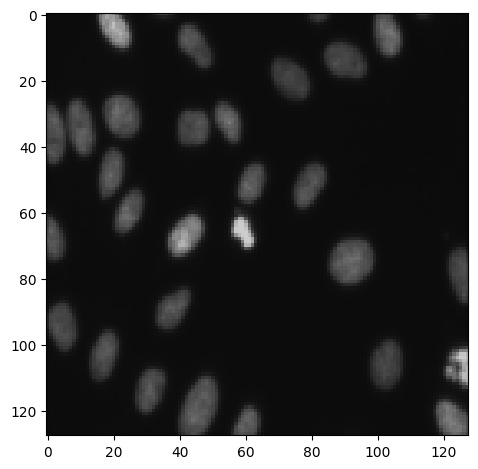

<ipython-input-49-257671d3a522>:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(np.squeeze(Y_train[image_x]))


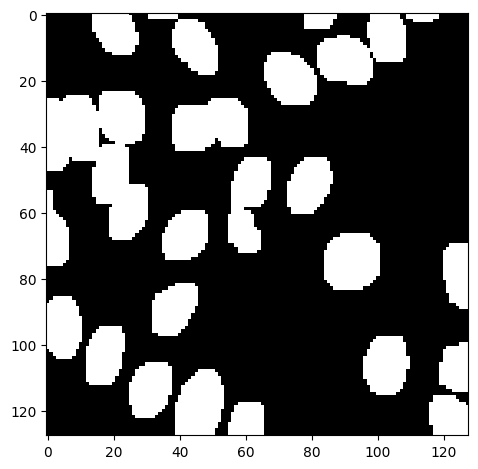

In [49]:
image_x=random.randint(0,len(train_ids))
imshow(X_train[image_x])
plt.show()
imshow(np.squeeze(Y_train[image_x]))
plt.show()

- The code first picks a random image from the training dataset.
- Then, it displays the selected image and its corresponding mask (which is a binary mask).
- This allows you to visually compare how the mask matches the original image.

In [3]:
inputs=tf.keras.layers.Input((IMG_WIDTH,IMG_HEIGHT,IMG_CHANNELS))

This line defines the input layer of your neural network model.



In [4]:
s=tf.keras.layers.Lambda(lambda x:x/255)(inputs)

converting the input values to floating points as they are accepted by layers

In [5]:
c1=tf.keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(s)

1. **`Conv2D`**: Creates a 2D convolutional layer to extract features like edges or textures from images.
2. **16**: Specifies the number of filters the layer uses to learn 16 different features.
3. **(3, 3)**: The filter size is 3x3, scanning 3x3 blocks of pixels at a time.
4. **`activation='relu'`**: Uses ReLU activation to introduce non-linearity and improve learning.
5. **`kernel_initializer='he_normal'`**: Setting up the starting values of the filter in a smart way

In [6]:
c1=tf.keras.layers.Dropout(0.1)(c1)

dropping few pixels to prevent overfitting

In [7]:
c1=tf.keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c1)

In [8]:
p1=tf.keras.layers.MaxPooling2D((2,2))(c1)

- **MaxPooling2D**: Reduces image size by downsampling.
- **(2, 2)**: Uses a 2x2 window to select the highest value in each block.
- **(c1)**: Applies pooling to the output of the previous layer (`c1`).


Encoder Side


In [9]:
c2=tf.keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(p1)
c2=tf.keras.layers.Dropout(0.1)(c2)
c2=tf.keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c2)
p2=tf.keras.layers.MaxPooling2D((2,2))(c2)

c3=tf.keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(p2)
c3=tf.keras.layers.Dropout(0.1)(c3)
c3=tf.keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c3)
p3=tf.keras.layers.MaxPooling2D((2,2))(c3)

c4=tf.keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(p3)
c4=tf.keras.layers.Dropout(0.1)(c4)
c4=tf.keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c4)
p4=tf.keras.layers.MaxPooling2D((2,2))(c4)

c5=tf.keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(p4)
c5=tf.keras.layers.Dropout(0.1)(c5)
c5=tf.keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c5)

Decoder Side


In [10]:
u6=tf.keras.layers.Conv2DTranspose(128,(2,2),strides=(2,2),padding='same')(c5)
u6=tf.keras.layers.concatenate([u6,c4])
c6=tf.keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(u6)
c6=tf.keras.layers.Dropout(0.2)(c6)
c6=tf.keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c6)

u7=tf.keras.layers.Conv2DTranspose(128,(2,2),strides=(2,2),padding='same')(c6)
u7=tf.keras.layers.concatenate([u7,c3])
c7=tf.keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(u7)
c7=tf.keras.layers.Dropout(0.2)(c7)
c7=tf.keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c7)

u8=tf.keras.layers.Conv2DTranspose(128,(2,2),strides=(2,2),padding='same')(c7)
u8=tf.keras.layers.concatenate([u8,c2])
c8=tf.keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(u8)
c8=tf.keras.layers.Dropout(0.2)(c8)
c8=tf.keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c8)

u9=tf.keras.layers.Conv2DTranspose(128,(2,2),strides=(2,2),padding='same')(c8)
u9=tf.keras.layers.concatenate([u9,c1])
c9=tf.keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(u9)
c9=tf.keras.layers.Dropout(0.2)(c9)
c9=tf.keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c9)


1. **Upsampling with `Conv2DTranspose`:**
   - Doubles the spatial dimensions (height and width) of `c5` using a transposed convolution with 128 filters.

2. **Skip connection (`concatenate`)**:
   - Concatenates the upsampled feature map `u6` with `c4` (a feature map from an earlier layer), combining their information.

3. **First convolution (`Conv2D`)**:
   - Applies a 3x3 convolution with 128 filters and ReLU activation to the concatenated feature map, preserving spatial dimensions.

4. **Dropout**:
   - Applies 20% dropout to the output of the first convolution to prevent overfitting during training.

5. **Second convolution (`Conv2D`)**:
   - Applies another 3x3 convolution with 128 filters and ReLU activation to the output of the dropout layer, preserving spatial dimensions.

In [11]:
outputs=tf.keras.layers.Conv2D(1,(1,1),activation='sigmoid')(c9)

In [12]:
model=tf.keras.Model(inputs=[inputs],outputs=[outputs])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

- **optimizer='adam'**: Adam optimizer adjusts learning rates for each parameter, making it efficient for deep learning tasks by combining the benefits of AdaGrad and RMSProp.
- **loss='binary_crossentropy'**: This helps the model understand how far off its predictions are from the actual answers, especially when there are only two possible outcomes (like yes/no, 0/1). The goal is to reduce this "error" during training.
- **metrics=['accuracy']**: Accuracy tracks the percentage of correct predictions during training, helping evaluate model performance.

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 128, 128, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 16)   │            448 │ lambda[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 128, 128, 16)   │              0 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 16)   │          2,320 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 16)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 16)     │          2,320 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 64, 64, 16)     │              0 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 16)     │          2,320 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 16)     │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 16)     │          2,320 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 32, 32, 16)     │              0 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 16)     │          2,320 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 16)     │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 16, 16, 16)     │          2,320 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 16, 16, 16)     │              0 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 16, 16, 16)     │          2,320 │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 8, 8, 16)       │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)       

 Total params: 1,481,169 (5.65 MB)

 Trainable params: 1,481,169 (5.65 MB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters are the adjustments (like weights and biases) the model makes during training to improve its predictions. These changes help the model learn patterns and make better decisions over time.

In [14]:
checkpointer=tf.keras.callbacks.ModelCheckpoint('model_for_nuclei.h5',verbose=1,save_best_only=True)
callbacks=[
    tf.keras.callbacks.EarlyStopping(patience=2,monitor='val_loss'),
    tf.keras.callbacks.TensorBoard(log_dir='logs')
]

### 1. **ModelCheckpoint**:
   - **What it does**: It saves the model at certain points during training.
   - **Why it’s useful**: If the model improves (for example, its accuracy or loss gets better), it saves that version of the model so you don't lose your progress.
   - **In simple terms**: Think of it as a "save" button that automatically saves the best version of your model while training.

   - **Key terms**:
     - **'model_for_nuclei.h5'**: The file name where the model is saved.
     - **`save_best_only=True`**: Saves only the best model (based on validation loss). This prevents saving every model and just keeps the one with the best performance.

### 2. **EarlyStopping**:
   - **What it does**: It stops the model from training if it isn’t improving anymore.
   - **Why it’s useful**: If your model stops getting better after a few tries, continuing to train would waste time. Early stopping prevents that.
   - **In simple terms**: It's like pausing training when the model has “learned all it can,” preventing it from overfitting or training too long.

   - **Key terms**:
     - **`patience=2`**: If the model's performance doesn’t improve for 2 epochs (tries), training will stop early.
     - **`monitor='val_loss'`**: Looks at how well the model is doing on unseen data (validation data) to decide if it’s improving.

### 3. **TensorBoard**:
   - **What it does**: It helps you see how well your model is performing by showing visual graphs of its progress.
   - **Why it’s useful**: It gives you a way to track the model’s progress over time and helps you understand how well it’s learning.
   - **In simple terms**: It’s like a dashboard that shows you how your model is doing as it learns.

   - **Key terms**:
     - **`log_dir='logs'`**: A folder where all the training details will be saved. You can later use TensorBoard to view them.

### Putting it all together:
- **Callback**: A callback is a special function that runs at certain times during training. Here, you’ve used three callbacks:
  1. Save the best model with **ModelCheckpoint**.
  2. Stop training if the model stops improving with **EarlyStopping**.
  3. Track progress with **TensorBoard**.



In [54]:
results=model.fit(X_train,Y_train,validation_split=0.1,batch_size=16,epochs=25,callbacks=callbacks)

Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 601s 16s/step - accuracy: 0.9625 - loss: 0.0966 - val_accuracy: 0.9665 - val_loss: 0.0923
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 620s 16s/step - accuracy: 0.9636 - loss: 0.0930 - val_accuracy: 0.9675 - val_loss: 0.0832
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 621s 16s/step - accuracy: 0.9634 - loss: 0.0943 - val_accuracy: 0.9674 - val_loss: 0.0915
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 597s 16s/step - accuracy: 0.9664 - loss: 0.0865 - val_accuracy: 0.9668 - val_loss: 0.0914


In [55]:
idx=random.randint(0,len(X_train))

preds_train=model.predict(X_train[:int(X_train.shape[0]*0.9)],verbose=1)
preds_val=model.predict(X_train[int(X_train.shape[0]*0.9):],verbose=1)
preds_test=model.predict(X_test,verbose=1)

preds_train_t=(preds_train>0.5).astype(np.uint8)
preds_val_t=(preds_val>0.5).astype(np.uint8)
preds_test_t=(preds_test>0.5).astype(np.uint8)

18/19 ━━━━━━━━━━━━━━━━━━━━ 8s 9s/step 

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


19/19 ━━━━━━━━━━━━━━━━━━━━ 168s 9s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step


1. **`idx = random.randint(0, len(X_train))`**:
   - This generates a **random index** (`idx`) between `0` and the length of `X_train`. It's used to select a random image, though it's not used later in the code.

2. **`preds_train = model.predict(X_train[:int(X_train.shape[0]*0.9)], verbose=1)`**:
   - The model predicts the output for the **first 90%** of the training data (`X_train[:int(X_train.shape[0]*0.9)]`).
   - `verbose=1` shows the progress of the prediction.

3. **`preds_val = model.predict(X_train[int(X_train.shape[0]*0.9):], verbose=1)`**:
   - The model predicts the output for the **remaining 10%** of the training data (`X_train[int(X_train.shape[0]*0.9):]`).
   - This is used for validation.

4. **`preds_test = model.predict(X_test, verbose=1)`**:
   - The model predicts the output for the **test data** (`X_test`).

5. **`preds_train_t = (preds_train > 0.5).astype(np.uint8)`**:
   - Converts `preds_train` to **binary values**.
   - If the predicted value is greater than 0.5, it's set to `1` (True), otherwise, it's set to `0` (False).
   - It then changes the data type to **`np.uint8`** (0 or 1 values).

6. **`preds_val_t = (preds_val > 0.5).astype(np.uint8)`**:
   - Similar to the above, converts the predicted values for validation (`preds_val`) to binary values.

7. **`preds_test_t = (preds_test > 0.5).astype(np.uint8)`**:
   - Converts the predicted values for the test data (`preds_test`) to binary values.

### Summary:
- The model makes predictions for training, validation, and test data.
- Predicted values are converted to binary masks (0 or 1) based on a threshold of 0.5.


<ipython-input-56-c58de62fe224>:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(X_train[ix])
/usr/local/lib/python3.11/dist-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


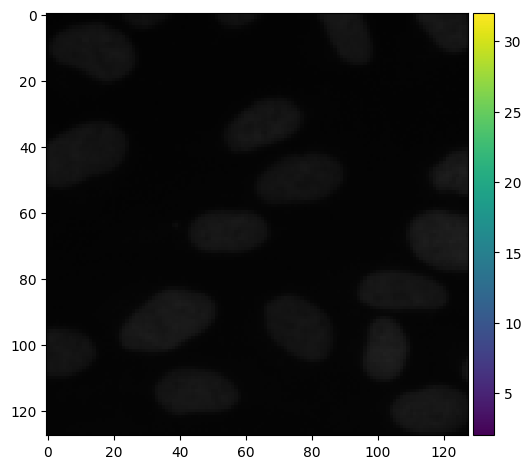

<ipython-input-56-c58de62fe224>:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(np.squeeze(Y_train[ix]))


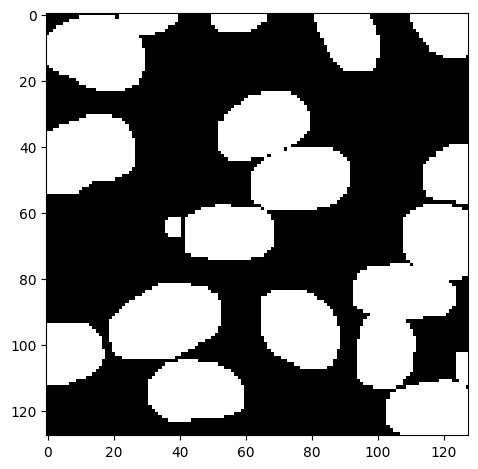

<ipython-input-56-c58de62fe224>:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(np.squeeze(preds_train_t[ix]))
/usr/local/lib/python3.11/dist-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


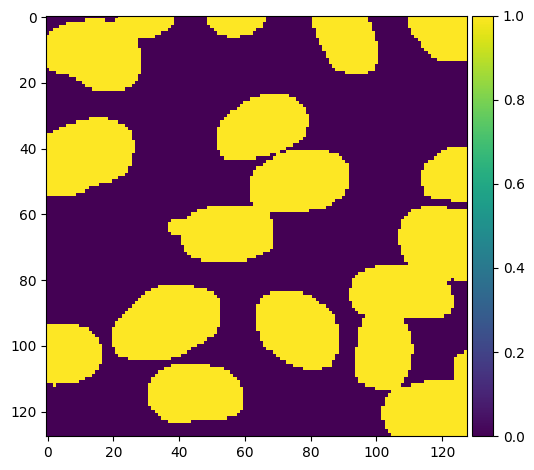

In [56]:
ix=random.randint(0,len(preds_train_t))
imshow(X_train[ix])
plt.show()
imshow(np.squeeze(Y_train[ix]))
plt.show()
imshow(np.squeeze(preds_train_t[ix]))
plt.show()

1. **`ix = random.randint(0, len(preds_train_t))`**:
   - Generates a **random index** `ix` to select a random sample from the predicted training data.

2. **`imshow(X_train[ix])`**:
   - Displays the **original image** (`X_train[ix]`) corresponding to the randomly selected index `ix`.

3. **`plt.show()`**:
   - Renders and shows the image of the **original image**.

4. **`imshow(np.squeeze(Y_train[ix]))`**:
   - Displays the **ground truth mask** (`Y_train[ix]`) corresponding to the selected image.
   - `np.squeeze()` removes unnecessary dimensions to make sure the mask is displayed correctly.

5. **`plt.show()`**:
   - Renders and shows the **ground truth mask**.

6. **`imshow(np.squeeze(preds_train_t[ix]))`**:
   - Displays the **predicted mask** (`preds_train_t[ix]`) corresponding to the selected image.
   - `np.squeeze()` is used to remove unnecessary dimensions.

7. **`plt.show()`**:
   - Renders and shows the **predicted mask**.

### Summary:
- The code shows three images:
  1. The **original image**.
  2. The **ground truth mask**.
  3. The **predicted mask**.
- This allows you to visually compare the actual and predicted masks.